# Tox21 Drug Toxicity Prediction — Modified Research Notebook

এই notebook-এ previous workflow refine করা হয়েছে তোমার requested changes অনুযায়ী:

- Evaluation metrics: **AUC-ROC, Accuracy, Balanced Accuracy, F1-score**
- **Linear SVM বাদ**, এখন **RBF SVM** use করা হয়েছে
- **Naive Bayes বাদ** দেওয়া হয়েছে
- **3-fold cross-validation** add করা হয়েছে
- Visual representation improve করা হয়েছে provided screenshot style অনুসারে
- Possible advanced hybrid: **CapsNet + SVM (RBF)** add করা হয়েছে

Target: **Tox21 multi-label binary toxicity prediction** with missing labels and severe class imbalance.

## 0. Environment setup

RDKit molecular fingerprint/descriptor বানানোর জন্য দরকার। কোনো package missing হলে নিচের install line uncomment করে run করবে।

In [1]:
# Colab/Kaggle/local environment এ দরকার হলে uncomment করে run করো:
# !pip -q install rdkit-pypi xgboost lightgbm imbalanced-learn tensorflow joblib

## 1. Import libraries

এই অংশে data handling, plotting, ML, metric, CV এবং model saving tools import করা হলো।

In [2]:
import os
import math
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 220)

print("Basic libraries imported")

Basic libraries imported


In [3]:
from sklearn.base import clone
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
)
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

from scipy.special import expit
import joblib

print("Scikit-learn tools imported")

Scikit-learn tools imported


In [4]:
try:
    from rdkit import Chem
    from rdkit.Chem import AllChem, MACCSkeys, Descriptors, rdMolDescriptors
    from rdkit.Chem.MolStandardize import rdMolStandardize
    from rdkit import RDLogger
    RDLogger.DisableLog("rdApp.*")
    RDKIT_AVAILABLE = True
    print("RDKit available")
except Exception as e:
    RDKIT_AVAILABLE = False
    print("RDKit import failed:", e)

RDKit available


In [5]:
try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
    print("XGBoost available")
except Exception as e:
    XGB_AVAILABLE = False
    print("XGBoost unavailable:", e)

try:
    from lightgbm import LGBMClassifier
    LGBM_AVAILABLE = True
    print("LightGBM available")
except Exception as e:
    LGBM_AVAILABLE = False
    print("LightGBM unavailable:", e)

try:
    from imblearn.over_sampling import SMOTE
    IMBLEARN_AVAILABLE = True
    print("imbalanced-learn available")
except Exception as e:
    IMBLEARN_AVAILABLE = False
    print("imbalanced-learn unavailable:", e)

XGBoost available
LightGBM available
imbalanced-learn available


In [6]:
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    TF_AVAILABLE = True
    print("TensorFlow available:", tf.__version__)
except Exception as e:
    TF_AVAILABLE = False
    print("TensorFlow unavailable. Deep learning blocks will be skipped:", e)

TensorFlow available: 2.21.0


## 2. Global configuration

Reproducibility, split ratio, CV folds এবং result folder define করা হলো।

In [7]:
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

N_BITS = 2048
RADIUS = 2
TRAIN_SIZE = 0.70
VAL_SIZE = 0.10
TEST_SIZE = 0.20
N_SPLITS_CV = 3

N_ESTIMATORS = 300
SVM_C = 5.0
SVM_GAMMA = "scale"

DL_EPOCHS = 35
DL_BATCH_SIZE = 128
DL_PATIENCE = 7
DL_LEARNING_RATE = 1e-3

# Runtime অনেক বেশি হলে False করা যায়। Research final run-এর জন্য True রাখা হয়েছে।
RUN_3FOLD_CV = True
RUN_DEEP_MODELS = True
RUN_CAPSNET_SVM = True

RESULT_DIR = Path("tox21_modified_outputs")
RESULT_DIR.mkdir(exist_ok=True)

print("Configuration ready")

Configuration ready


## 3. Load Tox21 dataset

Notebook একই folder, `/mnt/data`, অথবা Colab `/content` path থেকে `tox21.csv` খুঁজবে।

In [8]:
possible_paths = [
    Path("tox21.csv"),
    Path("/mnt/data/tox21.csv"),
    Path("/content/tox21.csv"),
    Path("../input/tox21/tox21.csv"),
]

DATA_PATH = next((p for p in possible_paths if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("tox21.csv পাওয়া যায়নি। Notebook-এর পাশে tox21.csv রাখো।")

df_raw = pd.read_csv(DATA_PATH)
print("Using dataset:", DATA_PATH)
print("Raw shape:", df_raw.shape)
df_raw.head()

Using dataset: tox21.csv
Raw shape: (7831, 14)


,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53,mol_id,smiles
0,0.0,0.0,1.0,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,TOX3021,CCOc1ccc2nc(S(N)(=O)=O)sc2c1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3020,CCN1C(=O)NC(c2ccccc2)C1=O
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,TOX3024,CC[C@]1(O)CC[C@H]2[C@@H]3CCC4=CCCC[C@@H]4[C@H]...
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3027,CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,TOX20800,CC(O)(P(=O)(O)O)P(=O)(O)O


In [9]:
TARGET_COLS = [c for c in df_raw.columns if c not in ["mol_id", "smiles"]]
print("Number of Tox21 endpoints:", len(TARGET_COLS))
print(TARGET_COLS)

for col in TARGET_COLS:
    df_raw[col] = pd.to_numeric(df_raw[col], errors="coerce")

Number of Tox21 endpoints: 12
['NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase', 'NR-ER', 'NR-ER-LBD', 'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53']


## 4. Dataset challenge table: missing values and imbalance

Tox21-এ অনেক endpoint-এ label missing এবং toxic positive class খুব কম। তাই accuracy একা যথেষ্ট নয়।

In [10]:
def make_endpoint_summary(df, target_cols):
    rows = []
    total_n = len(df)
    for col in target_cols:
        y = df[col]
        y_labeled = y.dropna().astype(int)
        n_pos = int((y_labeled == 1).sum())
        n_neg = int((y_labeled == 0).sum())
        n_missing = int(y.isna().sum())
        labeled = int(len(y_labeled))
        pos_rate = 100 * n_pos / max(labeled, 1)
        miss_rate = 100 * n_missing / max(total_n, 1)
        ratio = n_neg / max(n_pos, 1)
        rows.append({
            "Endpoint": col,
            "Labeled": labeled,
            "Toxic (1)": n_pos,
            "Non-Toxic (0)": n_neg,
            "Missing": n_missing,
            "Missing %": miss_rate,
            "Pos Rate %": pos_rate,
            "Imbalance": f"{ratio:.1f} : 1",
            "RatioValue": ratio,
        })
    return pd.DataFrame(rows)

endpoint_summary = make_endpoint_summary(df_raw, TARGET_COLS)
endpoint_summary_display = endpoint_summary.drop(columns=["RatioValue"]).copy()
endpoint_summary_display["Missing %"] = endpoint_summary_display["Missing %"].round(1)
endpoint_summary_display["Pos Rate %"] = endpoint_summary_display["Pos Rate %"].round(1)

print(endpoint_summary_display.to_string(index=False))
endpoint_summary_display

     Endpoint  Labeled  Toxic (1)  Non-Toxic (0)  Missing  Missing %  Pos Rate % Imbalance
        NR-AR     7265        309           6956      566        7.2         4.3  22.5 : 1
    NR-AR-LBD     6758        237           6521     1073       13.7         3.5  27.5 : 1
       NR-AhR     6549        768           5781     1282       16.4        11.7   7.5 : 1
 NR-Aromatase     5821        300           5521     2010       25.7         5.2  18.4 : 1
        NR-ER     6193        793           5400     1638       20.9        12.8   6.8 : 1
    NR-ER-LBD     6955        350           6605      876       11.2         5.0  18.9 : 1
NR-PPAR-gamma     6450        186           6264     1381       17.6         2.9  33.7 : 1
       SR-ARE     5832        942           4890     1999       25.5        16.2   5.2 : 1
     SR-ATAD5     7072        264           6808      759        9.7         3.7  25.8 : 1
       SR-HSE     6467        372           6095     1364       17.4         5.8  16.4 : 1

,Endpoint,Labeled,Toxic (1),Non-Toxic (0),Missing,Missing %,Pos Rate %,Imbalance
0,NR-AR,7265,309,6956,566,7.2,4.3,22.5 : 1
1,NR-AR-LBD,6758,237,6521,1073,13.7,3.5,27.5 : 1
2,NR-AhR,6549,768,5781,1282,16.4,11.7,7.5 : 1
3,NR-Aromatase,5821,300,5521,2010,25.7,5.2,18.4 : 1
4,NR-ER,6193,793,5400,1638,20.9,12.8,6.8 : 1
5,NR-ER-LBD,6955,350,6605,876,11.2,5.0,18.9 : 1
6,NR-PPAR-gamma,6450,186,6264,1381,17.6,2.9,33.7 : 1
7,SR-ARE,5832,942,4890,1999,25.5,16.2,5.2 : 1
8,SR-ATAD5,7072,264,6808,759,9.7,3.7,25.8 : 1
9,SR-HSE,6467,372,6095,1364,17.4,5.8,16.4 : 1


## 5. Visual EDA: missing labels and class imbalance

Red = severe issue, Orange = moderate, Green = acceptable. Screenshot-style horizontal bar chart তৈরি করা হলো।

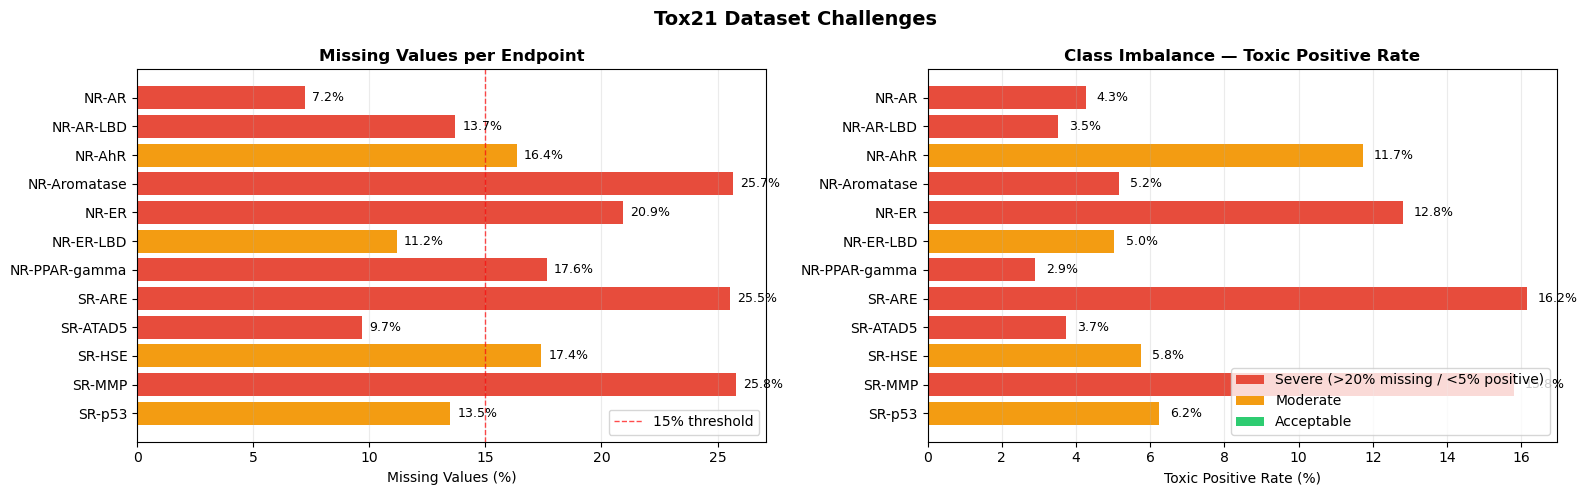

In [11]:
def severity_color(missing_pct, pos_rate):
    if missing_pct > 20 or pos_rate < 5:
        return "#e74c3c"   # severe red
    if missing_pct > 15 or pos_rate < 8:
        return "#f39c12"   # moderate orange
    return "#2ecc71"       # acceptable green

summary_plot = endpoint_summary.copy()
summary_plot = summary_plot.iloc[::-1].reset_index(drop=True)
colors = [severity_color(m, p) for m, p in zip(summary_plot["Missing %"], summary_plot["Pos Rate %"])]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].barh(summary_plot["Endpoint"], summary_plot["Missing %"], color=colors)
axes[0].axvline(15, color="red", linestyle="--", linewidth=1, alpha=0.7, label="15% threshold")
axes[0].set_title("Missing Values per Endpoint", fontweight="bold")
axes[0].set_xlabel("Missing Values (%)")
axes[0].grid(axis="x", alpha=0.25)
axes[0].legend(loc="lower right")
for i, v in enumerate(summary_plot["Missing %"]):
    axes[0].text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=9)

axes[1].barh(summary_plot["Endpoint"], summary_plot["Pos Rate %"], color=colors)
axes[1].set_title("Class Imbalance — Toxic Positive Rate", fontweight="bold")
axes[1].set_xlabel("Toxic Positive Rate (%)")
axes[1].grid(axis="x", alpha=0.25)
for i, v in enumerate(summary_plot["Pos Rate %"]):
    axes[1].text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=9)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#e74c3c", label="Severe (>20% missing / <5% positive)"),
    Patch(facecolor="#f39c12", label="Moderate"),
    Patch(facecolor="#2ecc71", label="Acceptable"),
]
axes[1].legend(handles=legend_elements, loc="lower right")

fig.suptitle("Tox21 Dataset Challenges", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

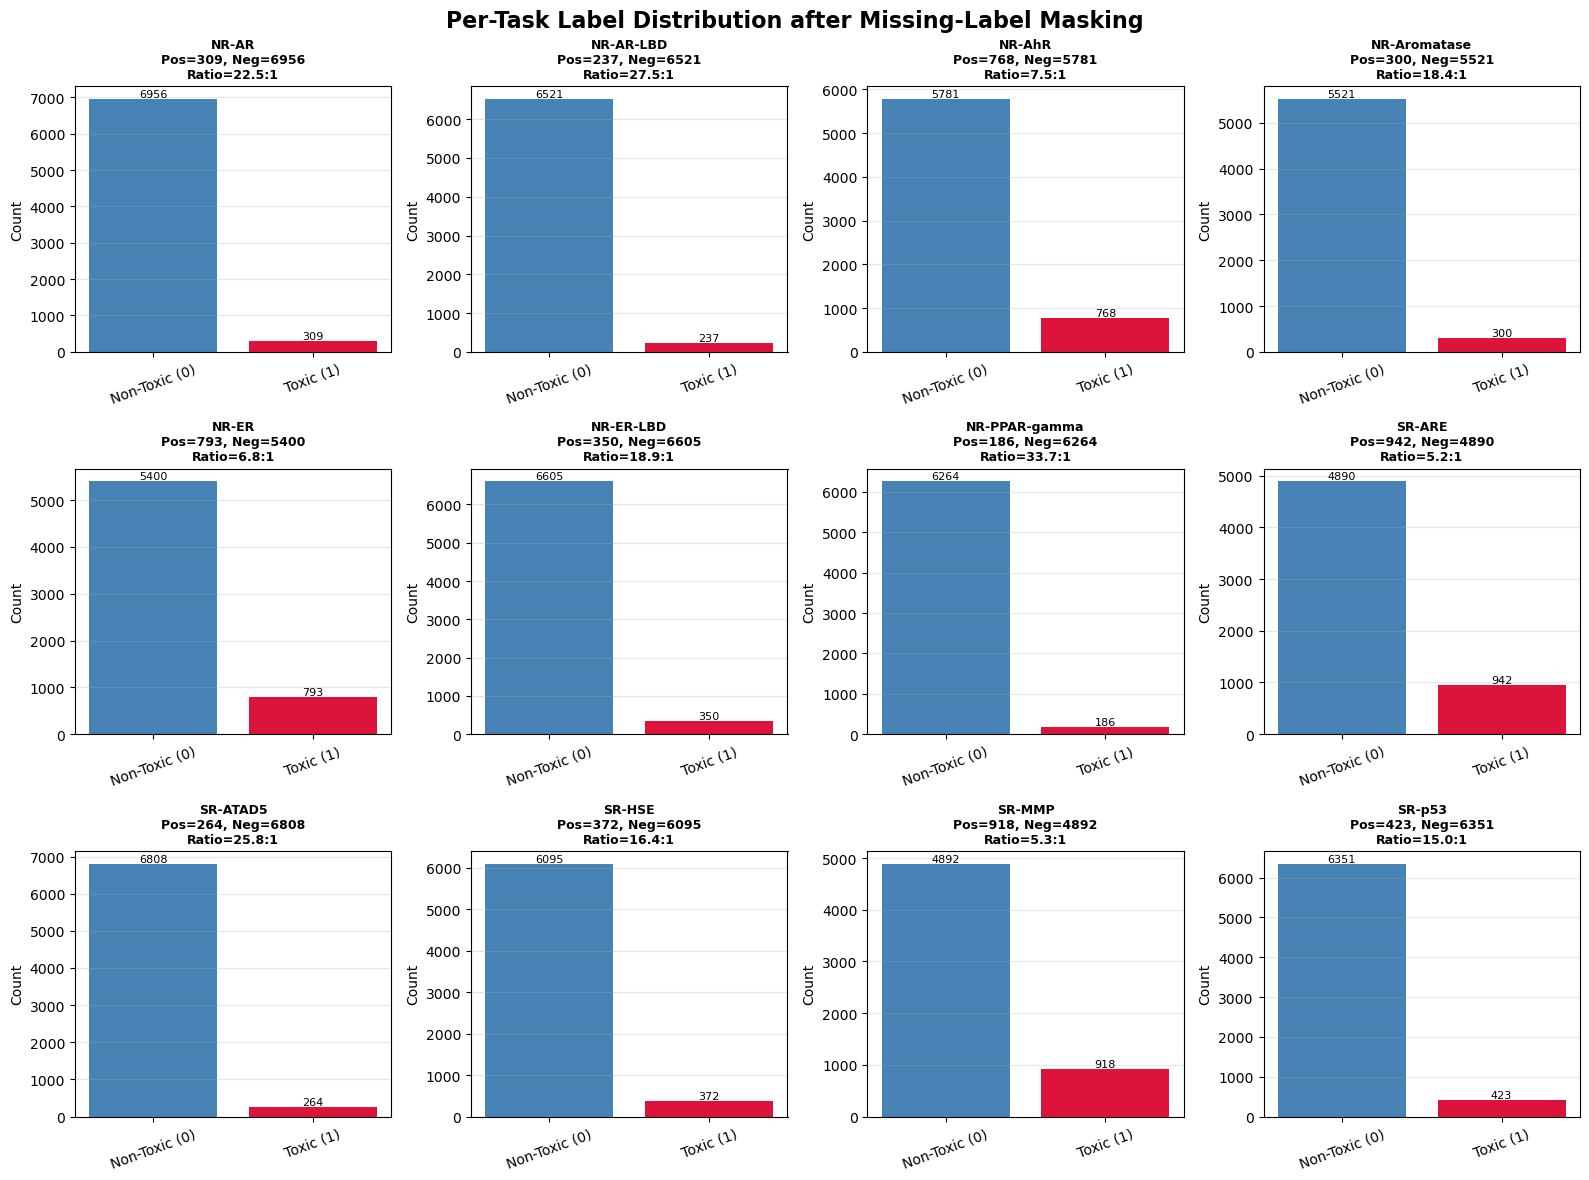

In [12]:
# ==========================================================
# Per-Task Label Distribution after Missing-Label Masking
# ==========================================================

import math
import matplotlib.pyplot as plt

n_cols = 4
n_rows = math.ceil(len(TARGET_COLS) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 12))
axes = axes.ravel()

for i, task in enumerate(TARGET_COLS):

    # Remove missing labels
    y_valid = df_raw[task].dropna().astype(int)

    # Count positive & negative samples
    n_neg = int((y_valid == 0).sum())
    n_pos = int((y_valid == 1).sum())

    # Plot
    axes[i].bar(
        ["Non-Toxic (0)", "Toxic (1)"],
        [n_neg, n_pos],
        color=["steelblue", "crimson"]
    )

    # Title
    axes[i].set_title(
        f"{task}\nPos={n_pos}, Neg={n_neg}\nRatio={n_neg/max(n_pos,1):.1f}:1",
        fontsize=9,
        fontweight="bold"
    )

    axes[i].set_ylabel("Count")
    axes[i].grid(axis="y", alpha=0.30)

    # Value labels
    axes[i].text(
        0, n_neg,
        str(n_neg),
        ha="center",
        va="bottom",
        fontsize=8
    )

    axes[i].text(
        1, n_pos,
        str(n_pos),
        ha="center",
        va="bottom",
        fontsize=8
    )

    axes[i].tick_params(axis="x", labelrotation=20)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle(
    "Per-Task Label Distribution after Missing-Label Masking",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

## 6. Chemical preprocessing

Research-quality preprocessing: invalid SMILES remove, largest fragment choose, normalize, uncharge, canonical SMILES generate।

In [13]:
if not RDKIT_AVAILABLE:
    raise ImportError("RDKit দরকার। Install: pip install rdkit-pypi")

normalizer = rdMolStandardize.Normalizer()
uncharger = rdMolStandardize.Uncharger()
fragment_chooser = rdMolStandardize.LargestFragmentChooser()

def clean_smiles(smiles):
    try:
        mol = Chem.MolFromSmiles(str(smiles))
        if mol is None:
            return None, None
        mol = fragment_chooser.choose(mol)
        mol = normalizer.normalize(mol)
        mol = uncharger.uncharge(mol)
        Chem.SanitizeMol(mol)
        can = Chem.MolToSmiles(mol, canonical=True)
        return can, mol
    except Exception:
        return None, None

cleaned = df_raw["smiles"].apply(clean_smiles)
df = df_raw.copy()
df["canonical_smiles"] = [x[0] for x in cleaned]
df["mol"] = [x[1] for x in cleaned]

invalid_mask = df["mol"].isna()
print("Invalid SMILES:", int(invalid_mask.sum()))

df = df.loc[~invalid_mask].reset_index(drop=True)
print("After invalid removal:", df.shape)

Invalid SMILES: 9
After invalid removal: (7822, 16)


In [14]:
# Duplicate canonical SMILES check
n_dups = int(df["canonical_smiles"].duplicated().sum())
print("Duplicate canonical SMILES:", n_dups)

if n_dups > 0:
    # Duplicate থাকলে label-wise first non-null aggregation করা হবে।
    agg_dict = {"smiles": "first", "mol_id": "first", "mol": "first"}
    for col in TARGET_COLS:
        agg_dict[col] = lambda s: s.dropna().iloc[0] if len(s.dropna()) else np.nan
    df = df.groupby("canonical_smiles", as_index=False).agg(agg_dict)
    print("After duplicate aggregation:", df.shape)

Duplicate canonical SMILES: 211
After duplicate aggregation: (7611, 16)


## 7. Feature engineering

Morgan ECFP4, MACCS keys, এবং selected RDKit physicochemical descriptors combine করা হয়েছে।

In [15]:
def morgan_fp(mol, n_bits=N_BITS, radius=RADIUS):
    arr = np.zeros((n_bits,), dtype=np.int8)
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)
    from rdkit import DataStructs
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

def maccs_fp(mol):
    arr = np.zeros((167,), dtype=np.int8)
    fp = MACCSkeys.GenMACCSKeys(mol)
    from rdkit import DataStructs
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

DESC_FUNCS = {
    "MolWt": Descriptors.MolWt,
    "MolLogP": Descriptors.MolLogP,
    "TPSA": Descriptors.TPSA,
    "NumHDonors": Descriptors.NumHDonors,
    "NumHAcceptors": Descriptors.NumHAcceptors,
    "NumRotatableBonds": Descriptors.NumRotatableBonds,
    "RingCount": Descriptors.RingCount,
    "HeavyAtomCount": Descriptors.HeavyAtomCount,
    "FractionCSP3": Descriptors.FractionCSP3,
    "NumAromaticRings": rdMolDescriptors.CalcNumAromaticRings,
    "NumAliphaticRings": rdMolDescriptors.CalcNumAliphaticRings,
}

def rdkit_desc(mol):
    values = []
    for name, func in DESC_FUNCS.items():
        try:
            values.append(float(func(mol)))
        except Exception:
            values.append(np.nan)
    return values

In [16]:
print("Generating Morgan fingerprints...")
X_morgan = np.vstack(df["mol"].apply(morgan_fp).values).astype(np.float32)
print("Morgan shape:", X_morgan.shape)

print("Generating MACCS keys...")
X_maccs = np.vstack(df["mol"].apply(maccs_fp).values).astype(np.float32)
print("MACCS shape:", X_maccs.shape)

print("Generating RDKit descriptors...")
X_desc_raw = np.vstack(df["mol"].apply(rdkit_desc).values).astype(np.float32)
desc_names = list(DESC_FUNCS.keys())
print("Descriptor shape:", X_desc_raw.shape)

Generating Morgan fingerprints...
Morgan shape: (7611, 2048)
Generating MACCS keys...
MACCS shape: (7611, 167)
Generating RDKit descriptors...
Descriptor shape: (7611, 11)


In [17]:
# Descriptor imputation + scaling
imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()
X_desc = scaler.fit_transform(imputer.fit_transform(X_desc_raw)).astype(np.float32)

# Final feature matrix: Morgan + MACCS + scaled descriptors
X = np.hstack([X_morgan, X_maccs, X_desc]).astype(np.float32)
Y = df[TARGET_COLS].values.astype(np.float32)

print("Final X shape:", X.shape)
print("Y shape:", Y.shape)
print("Missing labels in Y:", int(np.isnan(Y).sum()))

Final X shape: (7611, 2226)
Y shape: (7611, 12)
Missing labels in Y: 15550


## 8. Train / Validation / Test split = 70 / 10 / 20

Missing labels split করার সময় target হিসেবে use করা হয়নি। Stratification-এর জন্য `any_toxic` indicator use করা হয়েছে।

In [18]:
# Row-level stratification: at least one observed toxic endpoint আছে কিনা
any_toxic = np.nanmax(np.where(np.isnan(Y), 0, Y), axis=1).astype(int)

idx_all = np.arange(len(df))
idx_train, idx_temp = train_test_split(
    idx_all,
    test_size=(VAL_SIZE + TEST_SIZE),
    random_state=SEED,
    stratify=any_toxic,
)

relative_test_size = TEST_SIZE / (VAL_SIZE + TEST_SIZE)
idx_val, idx_test = train_test_split(
    idx_temp,
    test_size=relative_test_size,
    random_state=SEED,
    stratify=any_toxic[idx_temp],
)

X_train, Y_train = X[idx_train], Y[idx_train]
X_val, Y_val = X[idx_val], Y[idx_val]
X_test, Y_test = X[idx_test], Y[idx_test]

print("Train:", X_train.shape, Y_train.shape)
print("Validation:", X_val.shape, Y_val.shape)
print("Test:", X_test.shape, Y_test.shape)
print("Split ratio:", len(idx_train), len(idx_val), len(idx_test))

Train: (5327, 2226) (5327, 12)
Validation: (761, 2226) (761, 12)
Test: (1523, 2226) (1523, 12)
Split ratio: 5327 761 1523


In [19]:
split_df = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "rows": [len(idx_train), len(idx_val), len(idx_test)],
    "percentage": [100*len(idx_train)/len(df), 100*len(idx_val)/len(df), 100*len(idx_test)/len(df)]
})
split_df

,split,rows,percentage
0,train,5327,69.990803
1,validation,761,9.998686
2,test,1523,20.010511


## 9. Metric functions and threshold tuning

এই notebook-এ requested metrics only রাখা হয়েছে: **AUC-ROC, Accuracy, Balanced Accuracy, F1-score**।

In [20]:
def safe_auc(y_true, y_score):
    y_true = np.asarray(y_true).astype(int)
    if len(np.unique(y_true)) < 2:
        return np.nan
    try:
        return roc_auc_score(y_true, y_score)
    except Exception:
        return np.nan

def threshold_search(y_true, y_score, metric="f1"):
    # Validation set ব্যবহার করে endpoint-wise threshold tune করা হয়।
    thresholds = np.linspace(0.05, 0.95, 91)
    best_t, best_s = 0.5, -1
    y_true = np.asarray(y_true).astype(int)
    for t in thresholds:
        pred = (y_score >= t).astype(int)
        if metric == "balanced_accuracy":
            s = balanced_accuracy_score(y_true, pred)
        else:
            s = f1_score(y_true, pred, zero_division=0)
        if s > best_s:
            best_s = s
            best_t = float(t)
    return best_t, best_s

def classification_metrics(y_true, y_score, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    y_pred = (y_score >= threshold).astype(int)
    return {
        "AUC-ROC": safe_auc(y_true, y_score),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred, zero_division=0),
    }

def model_scores(model, X_data):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_data)[:, 1]
    if hasattr(model, "decision_function"):
        return expit(model.decision_function(X_data))
    return model.predict(X_data).astype(float)

In [21]:
all_results = {}
all_cv_results = {}
all_test_predictions = {}
all_thresholds = {}

summary_columns = ["Model", "Mean AUC-ROC", "Mean Accuracy", "Mean Balanced Accuracy", "Mean F1"]

def summarize_results(results_df, model_name):
    means = results_df[["AUC-ROC", "Accuracy", "Balanced Accuracy", "F1"]].mean(numeric_only=True)
    return {
        "Model": model_name,
        "Mean AUC-ROC": means["AUC-ROC"],
        "Mean Accuracy": means["Accuracy"],
        "Mean Balanced Accuracy": means["Balanced Accuracy"],
        "Mean F1": means["F1"],
    }

def print_compact_result(model_name, df_result):
    s = summarize_results(df_result, model_name)
    print(f"✅ {model_name:24s} | AUC={s['Mean AUC-ROC']:.3f} | Acc={s['Mean Accuracy']:.3f} | BalAcc={s['Mean Balanced Accuracy']:.3f} | F1={s['Mean F1']:.3f}")

## 10. 3-fold CV + final test helper for single-task ML models

প্রতিটি endpoint আলাদা binary classification task হিসেবে train করা হবে। Missing labels বাদ দিয়ে train/CV/evaluate করা হবে।

In [22]:
def run_single_task_model(
    model_name,
    model_factory,
    X_train,
    Y_train,
    X_val,
    Y_val,
    X_test,
    Y_test,
    use_smote=False,
):
    endpoint_rows = []
    cv_rows = []
    pred_store = {}
    threshold_store = {}

    print(f"⏳ Running {model_name} ...")

    for task_idx, task in enumerate(TARGET_COLS):
        # Non-missing training labels
        tr_mask = ~np.isnan(Y_train[:, task_idx])
        va_mask = ~np.isnan(Y_val[:, task_idx])
        te_mask = ~np.isnan(Y_test[:, task_idx])

        Xtr, ytr = X_train[tr_mask], Y_train[tr_mask, task_idx].astype(int)
        Xva, yva = X_val[va_mask], Y_val[va_mask, task_idx].astype(int)
        Xte, yte = X_test[te_mask], Y_test[te_mask, task_idx].astype(int)

        n_pos = int((ytr == 1).sum())
        n_neg = int((ytr == 0).sum())

        if len(np.unique(ytr)) < 2 or len(np.unique(yte)) < 2:
            print(f"   ⚠️ {task}: skipped due to one-class data")
            continue

        # 3-fold CV on training set only
        if RUN_3FOLD_CV:
            cv = StratifiedKFold(n_splits=N_SPLITS_CV, shuffle=True, random_state=SEED)
            fold_metrics = []
            for fold_id, (tr_i, cv_i) in enumerate(cv.split(Xtr, ytr), start=1):
                X_fold_train, y_fold_train = Xtr[tr_i], ytr[tr_i]
                X_fold_val, y_fold_val = Xtr[cv_i], ytr[cv_i]

                model_cv = model_factory(y_fold_train)

                if use_smote and IMBLEARN_AVAILABLE and (y_fold_train.sum() >= 3):
                    k_neighbors = max(1, min(5, int(y_fold_train.sum()) - 1))
                    sm = SMOTE(random_state=SEED, k_neighbors=k_neighbors)
                    X_fold_train, y_fold_train = sm.fit_resample(X_fold_train, y_fold_train)

                model_cv.fit(X_fold_train, y_fold_train)
                cv_score = model_scores(model_cv, X_fold_val)
                fold_metric = classification_metrics(y_fold_val, cv_score, threshold=0.5)
                fold_metric.update({"Endpoint": task, "Fold": fold_id})
                fold_metrics.append(fold_metric)

            fold_df = pd.DataFrame(fold_metrics)
            cv_rows.append({
                "Endpoint": task,
                "CV AUC-ROC Mean": fold_df["AUC-ROC"].mean(),
                "CV AUC-ROC Std": fold_df["AUC-ROC"].std(),
                "CV Accuracy Mean": fold_df["Accuracy"].mean(),
                "CV Balanced Accuracy Mean": fold_df["Balanced Accuracy"].mean(),
                "CV F1 Mean": fold_df["F1"].mean(),
            })

        # Final fit on train; threshold tuning on validation; final evaluation on test
        model = model_factory(ytr)
        Xtr_fit, ytr_fit = Xtr, ytr
        if use_smote and IMBLEARN_AVAILABLE and (ytr.sum() >= 3):
            k_neighbors = max(1, min(5, int(ytr.sum()) - 1))
            sm = SMOTE(random_state=SEED, k_neighbors=k_neighbors)
            Xtr_fit, ytr_fit = sm.fit_resample(Xtr_fit, ytr_fit)

        model.fit(Xtr_fit, ytr_fit)

        val_score = model_scores(model, Xva) if len(Xva) else model_scores(model, Xte)
        val_y = yva if len(Xva) else yte
        best_threshold, _ = threshold_search(val_y, val_score, metric="f1")

        test_score = model_scores(model, Xte)
        metrics = classification_metrics(yte, test_score, threshold=best_threshold)

        row = {
            "Endpoint": task,
            "n_train_pos": n_pos,
            "n_train_neg": n_neg,
            "Threshold": best_threshold,
            **metrics,
        }
        endpoint_rows.append(row)

        pred_store[task] = {
            "y_true": yte,
            "y_score": test_score,
            "y_pred": (test_score >= best_threshold).astype(int),
        }
        threshold_store[task] = best_threshold

    result_df = pd.DataFrame(endpoint_rows)
    cv_df = pd.DataFrame(cv_rows)

    all_results[model_name] = result_df
    all_cv_results[model_name] = cv_df
    all_test_predictions[model_name] = pred_store
    all_thresholds[model_name] = threshold_store

    print_compact_result(model_name, result_df)
    return result_df, cv_df

## 11. Model 1 — Random Forest

Class imbalance handle করার জন্য `class_weight="balanced_subsample"` use করা হয়েছে।

In [23]:
def rf_factory(y):
    return RandomForestClassifier(
        n_estimators=N_ESTIMATORS,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=SEED,
    )

rf_results, rf_cv = run_single_task_model("Random Forest", rf_factory, X_train, Y_train, X_val, Y_val, X_test, Y_test)
rf_results

⏳ Running Random Forest ...
✅ Random Forest            | AUC=0.845 | Acc=0.922 | BalAcc=0.721 | F1=0.483


,Endpoint,n_train_pos,n_train_neg,Threshold,AUC-ROC,Accuracy,Balanced Accuracy,F1
0,NR-AR,211,4721,0.46,0.798446,0.975955,0.760579,0.638298
1,NR-AR-LBD,159,4444,0.72,0.838415,0.977255,0.717570,0.583333
2,NR-AhR,529,3935,0.39,0.898394,0.891270,0.800341,0.607450
3,NR-Aromatase,191,3762,0.34,0.852771,0.950178,0.672612,0.450980
4,NR-ER,540,3692,0.39,0.713785,0.852349,0.666342,0.417219
5,NR-ER-LBD,236,4511,0.46,0.801991,0.957463,0.685280,0.477064
6,NR-PPAR-gamma,126,4269,0.23,0.872434,0.952000,0.722952,0.318182
7,SR-ARE,630,3355,0.38,0.852709,0.837577,0.750990,0.560570
8,SR-ATAD5,192,4612,0.35,0.854223,0.956364,0.651154,0.318182
9,SR-HSE,259,4153,0.28,0.850192,0.909377,0.744025,0.397906


## 12. Model 2 — Extra Trees

Random Forest-এর মতো ensemble, কিন্তু split randomization বেশি। Toxicity fingerprint data-তে strong baseline।

In [24]:
def et_factory(y):
    return ExtraTreesClassifier(
        n_estimators=N_ESTIMATORS,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced",
        n_jobs=-1,
        random_state=SEED,
    )

et_results, et_cv = run_single_task_model("Extra Trees", et_factory, X_train, Y_train, X_val, Y_val, X_test, Y_test)
et_results

⏳ Running Extra Trees ...
✅ Extra Trees              | AUC=0.837 | Acc=0.919 | BalAcc=0.711 | F1=0.465


,Endpoint,n_train_pos,n_train_neg,Threshold,AUC-ROC,Accuracy,Balanced Accuracy,F1
0,NR-AR,211,4721,0.77,0.825861,0.975955,0.718561,0.595238
1,NR-AR-LBD,159,4444,0.66,0.840357,0.977255,0.727593,0.594595
2,NR-AhR,529,3935,0.38,0.893453,0.877778,0.795394,0.581522
3,NR-Aromatase,191,3762,0.32,0.834906,0.941281,0.682577,0.431034
4,NR-ER,540,3692,0.43,0.708097,0.840604,0.631308,0.358108
5,NR-ER-LBD,236,4511,0.58,0.794095,0.957463,0.671361,0.457143
6,NR-PPAR-gamma,126,4269,0.24,0.851535,0.944000,0.718857,0.285714
7,SR-ARE,630,3355,0.42,0.833986,0.821773,0.707831,0.501229
8,SR-ATAD5,192,4612,0.36,0.832277,0.949818,0.659028,0.303030
9,SR-HSE,259,4153,0.34,0.842956,0.913318,0.725296,0.388889


## 13. Model 3 — XGBoost

Endpoint-wise `scale_pos_weight = negative / positive` use করা হয়েছে imbalance-aware training-এর জন্য।

In [25]:
if XGB_AVAILABLE:
    def xgb_factory(y):
        pos = max(int((y == 1).sum()), 1)
        neg = max(int((y == 0).sum()), 1)
        return XGBClassifier(
            n_estimators=350,
            max_depth=5,
            learning_rate=0.035,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_lambda=2.0,
            scale_pos_weight=neg / pos,
            eval_metric="logloss",
            tree_method="hist",
            n_jobs=-1,
            random_state=SEED,
        )

    xgb_results, xgb_cv = run_single_task_model("XGBoost", xgb_factory, X_train, Y_train, X_val, Y_val, X_test, Y_test)
    display(xgb_results)
else:
    print("XGBoost unavailable; skipped.")

⏳ Running XGBoost ...
✅ XGBoost                  | AUC=0.836 | Acc=0.922 | BalAcc=0.719 | F1=0.485


,Endpoint,n_train_pos,n_train_neg,Threshold,AUC-ROC,Accuracy,Balanced Accuracy,F1
0,NR-AR,211,4721,0.89,0.828324,0.978076,0.753281,0.651685
1,NR-AR-LBD,159,4444,0.92,0.821761,0.979530,0.748820,0.640000
2,NR-AhR,529,3935,0.52,0.889051,0.863492,0.789994,0.556701
3,NR-Aromatase,191,3762,0.37,0.852211,0.887900,0.727683,0.357143
4,NR-ER,540,3692,0.67,0.720006,0.869966,0.639626,0.392157
5,NR-ER-LBD,236,4511,0.80,0.807136,0.956716,0.664008,0.442308
6,NR-PPAR-gamma,126,4269,0.69,0.854500,0.972800,0.666271,0.370370
7,SR-ARE,630,3355,0.59,0.836848,0.858648,0.751007,0.581818
8,SR-ATAD5,192,4612,0.76,0.790165,0.965818,0.667286,0.389610
9,SR-HSE,259,4153,0.58,0.830270,0.913318,0.697550,0.360465


## 14. Model 4 — LightGBM

Fast gradient boosting model; class imbalance-এর জন্য `class_weight="balanced"`।

In [26]:
if LGBM_AVAILABLE:
    def lgbm_factory(y):
        return LGBMClassifier(
            n_estimators=450,
            learning_rate=0.03,
            num_leaves=31,
            subsample=0.85,
            colsample_bytree=0.85,
            class_weight="balanced",
            random_state=SEED,
            n_jobs=-1,
            verbose=-1,
        )

    lgbm_results, lgbm_cv = run_single_task_model("LightGBM", lgbm_factory, X_train, Y_train, X_val, Y_val, X_test, Y_test)
    display(lgbm_results)
else:
    print("LightGBM unavailable; skipped.")

⏳ Running LightGBM ...
✅ LightGBM                 | AUC=0.830 | Acc=0.923 | BalAcc=0.716 | F1=0.478


,Endpoint,n_train_pos,n_train_neg,Threshold,AUC-ROC,Accuracy,Balanced Accuracy,F1
0,NR-AR,211,4721,0.73,0.810521,0.973833,0.751070,0.610526
1,NR-AR-LBD,159,4444,0.50,0.807927,0.978014,0.778103,0.650602
2,NR-AhR,529,3935,0.65,0.886224,0.895238,0.714535,0.528571
3,NR-Aromatase,191,3762,0.30,0.830911,0.933274,0.670991,0.390244
4,NR-ER,540,3692,0.53,0.699903,0.849832,0.642254,0.380623
5,NR-ER-LBD,236,4511,0.85,0.792014,0.962687,0.667152,0.479167
6,NR-PPAR-gamma,126,4269,0.20,0.868339,0.963200,0.695021,0.342857
7,SR-ARE,630,3355,0.47,0.829699,0.834943,0.719943,0.525253
8,SR-ATAD5,192,4612,0.30,0.795316,0.952727,0.671782,0.329897
9,SR-HSE,259,4153,0.23,0.836466,0.899921,0.739029,0.374384


## 15. Model 5 — Logistic Regression

Interpretable classical baseline; imbalance handling with `class_weight="balanced"`।

In [27]:
def lr_factory(y):
    return LogisticRegression(
        C=1.0,
        penalty="l2",
        solver="liblinear",
        class_weight="balanced",
        max_iter=2000,
        random_state=SEED,
    )

lr_results, lr_cv = run_single_task_model("Logistic Regression", lr_factory, X_train, Y_train, X_val, Y_val, X_test, Y_test)
lr_results

⏳ Running Logistic Regression ...
✅ Logistic Regression      | AUC=0.792 | Acc=0.892 | BalAcc=0.706 | F1=0.420


,Endpoint,n_train_pos,n_train_neg,Threshold,AUC-ROC,Accuracy,Balanced Accuracy,F1
0,NR-AR,211,4721,0.87,0.779622,0.969590,0.732052,0.556701
1,NR-AR-LBD,159,4444,0.88,0.798567,0.975739,0.746853,0.600000
2,NR-AhR,529,3935,0.59,0.865472,0.881746,0.753623,0.549849
3,NR-Aromatase,191,3762,0.38,0.796831,0.911922,0.696374,0.369427
4,NR-ER,540,3692,0.45,0.660658,0.778523,0.621244,0.319588
5,NR-ER-LBD,236,4511,0.81,0.770510,0.950746,0.667823,0.421053
6,NR-PPAR-gamma,126,4269,0.18,0.811969,0.912800,0.719718,0.215827
7,SR-ARE,630,3355,0.40,0.770401,0.792801,0.726224,0.502110
8,SR-ATAD5,192,4612,0.76,0.788891,0.961455,0.642529,0.329114
9,SR-HSE,259,4153,0.25,0.777116,0.839243,0.686162,0.255474


## 16. Model 6 — SVM with RBF kernel

Requested change: **Linear SVM বাদ**, এখন **RBF SVM** use করা হচ্ছে।

In [28]:
def svm_rbf_factory(y):
    return SVC(
        kernel="rbf",
        C=SVM_C,
        gamma=SVM_GAMMA,
        probability=True,
        class_weight="balanced",
        cache_size=1000,
        random_state=SEED,
    )

svm_rbf_results, svm_rbf_cv = run_single_task_model("SVM (RBF)", svm_rbf_factory, X_train, Y_train, X_val, Y_val, X_test, Y_test)
svm_rbf_results

⏳ Running SVM (RBF) ...
✅ SVM (RBF)                | AUC=0.834 | Acc=0.921 | BalAcc=0.721 | F1=0.480


,Endpoint,n_train_pos,n_train_neg,Threshold,AUC-ROC,Accuracy,Balanced Accuracy,F1
0,NR-AR,211,4721,0.28,0.797412,0.970297,0.732421,0.562500
1,NR-AR-LBD,159,4444,0.41,0.870820,0.977255,0.747640,0.615385
2,NR-AhR,529,3935,0.35,0.896170,0.907937,0.752055,0.594406
3,NR-Aromatase,191,3762,0.12,0.836940,0.937722,0.702712,0.444444
4,NR-ER,540,3692,0.21,0.697053,0.841443,0.637451,0.367893
5,NR-ER-LBD,236,4511,0.37,0.792603,0.961194,0.666366,0.469388
6,NR-PPAR-gamma,126,4269,0.09,0.835691,0.954400,0.724180,0.329412
7,SR-ARE,630,3355,0.24,0.833442,0.816506,0.734136,0.526077
8,SR-ATAD5,192,4612,0.18,0.838842,0.958545,0.663533,0.344828
9,SR-HSE,259,4153,0.12,0.832903,0.907801,0.729319,0.380952


## 17. Model 7 — k-NN

Simple similarity-based baseline; molecular fingerprints-এর nearest-neighbor behavior compare করার জন্য রাখা হলো।

In [29]:
def knn_factory(y):
    return KNeighborsClassifier(
        n_neighbors=5,
        weights="distance",
        metric="jaccard",
        n_jobs=-1,
    )

# KNN-এর jaccard metric binary Morgan/MACCS features-এর জন্য বেশি natural। Descriptor অংশ বাদ দিয়ে fingerprint-only use করা হলো।
Xfp_train = np.hstack([X_morgan[idx_train], X_maccs[idx_train]]).astype(np.float32)
Xfp_val = np.hstack([X_morgan[idx_val], X_maccs[idx_val]]).astype(np.float32)
Xfp_test = np.hstack([X_morgan[idx_test], X_maccs[idx_test]]).astype(np.float32)

knn_results, knn_cv = run_single_task_model("k-NN (Jaccard)", knn_factory, Xfp_train, Y_train, Xfp_val, Y_val, Xfp_test, Y_test)
knn_results

⏳ Running k-NN (Jaccard) ...
✅ k-NN (Jaccard)           | AUC=0.770 | Acc=0.918 | BalAcc=0.694 | F1=0.437


,Endpoint,n_train_pos,n_train_neg,Threshold,AUC-ROC,Accuracy,Balanced Accuracy,F1
0,NR-AR,211,4721,0.62,0.783223,0.978076,0.736474,0.635294
1,NR-AR-LBD,159,4444,0.62,0.810148,0.975739,0.736830,0.589744
2,NR-AhR,529,3935,0.21,0.859860,0.874603,0.796335,0.577540
3,NR-Aromatase,191,3762,0.21,0.729724,0.929715,0.683785,0.396947
4,NR-ER,540,3692,0.41,0.659386,0.864094,0.607955,0.330579
5,NR-ER-LBD,236,4511,0.42,0.742526,0.957463,0.650481,0.424242
6,NR-PPAR-gamma,126,4269,0.20,0.769465,0.954400,0.707348,0.313253
7,SR-ARE,630,3355,0.40,0.757479,0.836699,0.659961,0.446429
8,SR-ATAD5,192,4612,0.41,0.714776,0.963636,0.576140,0.218750
9,SR-HSE,259,4153,0.19,0.752424,0.885737,0.710725,0.325581


## 18. Model 8 — MLP Classifier

Fingerprint + descriptor based shallow neural baseline।

In [30]:
def mlp_factory(y):
    return MLPClassifier(
        hidden_layer_sizes=(512, 256),
        activation="relu",
        alpha=1e-4,
        batch_size=128,
        learning_rate_init=1e-3,
        max_iter=120,
        early_stopping=True,
        validation_fraction=0.12,
        n_iter_no_change=12,
        random_state=SEED,
    )

mlp_results, mlp_cv = run_single_task_model("MLP", mlp_factory, X_train, Y_train, X_val, Y_val, X_test, Y_test)
mlp_results

⏳ Running MLP ...
✅ MLP                      | AUC=0.790 | Acc=0.919 | BalAcc=0.698 | F1=0.465


,Endpoint,n_train_pos,n_train_neg,Threshold,AUC-ROC,Accuracy,Balanced Accuracy,F1
0,NR-AR,211,4721,0.49,0.809823,0.980198,0.754386,0.674419
1,NR-AR-LBD,159,4444,0.09,0.771817,0.977255,0.767686,0.634146
2,NR-AhR,529,3935,0.26,0.877456,0.892857,0.759964,0.574132
3,NR-Aromatase,191,3762,0.05,0.755100,0.951957,0.622170,0.372093
4,NR-ER,540,3692,0.24,0.706513,0.805369,0.659262,0.376344
5,NR-ER-LBD,236,4511,0.33,0.783181,0.955970,0.656655,0.427184
6,NR-PPAR-gamma,126,4269,0.19,0.708351,0.976000,0.651077,0.375000
7,SR-ARE,630,3355,0.20,0.820931,0.808604,0.731499,0.517699
8,SR-ATAD5,192,4612,0.13,0.777891,0.954182,0.627523,0.275862
9,SR-HSE,259,4153,0.18,0.780202,0.930654,0.644279,0.333333


## 19. Deep learning utilities: masked loss for missing labels

Multi-task deep learning model-এ missing label ignore করার জন্য masked binary cross-entropy use করা হলো। Missing labels `-1` দিয়ে encode করা হবে।

In [31]:
def prepare_multitask_y(Y_array):
    return np.where(np.isnan(Y_array), -1.0, Y_array).astype(np.float32)

def evaluate_multitask_probabilities(model_name, prob_val, prob_test):
    endpoint_rows = []
    pred_store = {}
    threshold_store = {}

    for task_idx, task in enumerate(TARGET_COLS):
        va_mask = ~np.isnan(Y_val[:, task_idx])
        te_mask = ~np.isnan(Y_test[:, task_idx])
        yva = Y_val[va_mask, task_idx].astype(int)
        yte = Y_test[te_mask, task_idx].astype(int)

        if len(np.unique(yte)) < 2 or len(np.unique(yva)) < 2:
            continue

        val_score = prob_val[va_mask, task_idx]
        test_score = prob_test[te_mask, task_idx]
        best_threshold, _ = threshold_search(yva, val_score, metric="f1")
        metrics = classification_metrics(yte, test_score, threshold=best_threshold)

        endpoint_rows.append({
            "Endpoint": task,
            "n_train_pos": int(np.nansum(Y_train[:, task_idx] == 1)),
            "n_train_neg": int(np.nansum(Y_train[:, task_idx] == 0)),
            "Threshold": best_threshold,
            **metrics,
        })
        pred_store[task] = {
            "y_true": yte,
            "y_score": test_score,
            "y_pred": (test_score >= best_threshold).astype(int),
        }
        threshold_store[task] = best_threshold

    result_df = pd.DataFrame(endpoint_rows)
    all_results[model_name] = result_df
    all_test_predictions[model_name] = pred_store
    all_thresholds[model_name] = threshold_store
    print_compact_result(model_name, result_df)
    return result_df

if TF_AVAILABLE:
    def masked_binary_crossentropy(y_true, y_pred):
        mask = tf.cast(tf.not_equal(y_true, -1.0), tf.float32)
        y_clean = tf.where(tf.equal(y_true, -1.0), tf.zeros_like(y_true), y_true)
        bce = keras.backend.binary_crossentropy(y_clean, y_pred)
        return tf.reduce_sum(bce * mask) / (tf.reduce_sum(mask) + keras.backend.epsilon())

## 20. Model 9 — Multi-task DNN

DeepTox-style multitask DNN: 12 endpoints একসাথে learn করে, missing-label mask সহ।

In [32]:
if TF_AVAILABLE and RUN_DEEP_MODELS:
    tf.keras.utils.set_random_seed(SEED)

    def build_multitask_dnn(input_dim, n_tasks):
        inp = keras.Input(shape=(input_dim,), name="tox21_features")
        x = layers.Dense(1024, activation="relu")(inp)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.35)(x)
        x = layers.Dense(512, activation="relu")(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.30)(x)
        x = layers.Dense(256, activation="relu", name="dnn_features")(x)
        x = layers.Dropout(0.20)(x)
        out = layers.Dense(n_tasks, activation="sigmoid", name="toxicity_outputs")(x)
        model = keras.Model(inp, out, name="Multitask_DNN")
        model.compile(
            optimizer=keras.optimizers.Adam(DL_LEARNING_RATE),
            loss=masked_binary_crossentropy,
        )
        return model

    dnn_model = build_multitask_dnn(X_train.shape[1], len(TARGET_COLS))
    dnn_model.summary()
else:
    print("DNN block skipped because TensorFlow unavailable or RUN_DEEP_MODELS=False")

Model: "Multitask_DNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ tox21_features (InputLayer)     │ (None, 2226)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     2,280,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dnn_features (Dense)            │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ toxicity_outputs (Dense)        │ (None, 12)             │         3,084 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,945,804 (11.24 MB)

 Trainable params: 2,942,732 (11.23 MB)

 Non-trainable params: 3,072 (12.00 KB)

In [33]:
if TF_AVAILABLE and RUN_DEEP_MODELS:
    y_train_mt = prepare_multitask_y(Y_train)
    y_val_mt = prepare_multitask_y(Y_val)

    callbacks = [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=DL_PATIENCE, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", patience=3, factor=0.5, min_lr=1e-5),
    ]

    history_dnn = dnn_model.fit(
        X_train, y_train_mt,
        validation_data=(X_val, y_val_mt),
        epochs=DL_EPOCHS,
        batch_size=DL_BATCH_SIZE,
        callbacks=callbacks,
        verbose=1,
    )

    dnn_val_prob = dnn_model.predict(X_val, verbose=0)
    dnn_test_prob = dnn_model.predict(X_test, verbose=0)
    dnn_results = evaluate_multitask_probabilities("Multitask DNN", dnn_val_prob, dnn_test_prob)
    display(dnn_results)

Epoch 1/35
42/42 ━━━━━━━━━━━━━━━━━━━━ 9s 74ms/step - loss: 0.3266 - val_loss: 0.3259 - learning_rate: 0.0010
Epoch 2/35
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 0.1827 - val_loss: 0.2305 - learning_rate: 0.0010
Epoch 3/35
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 0.1439 - val_loss: 0.2082 - learning_rate: 0.0010
Epoch 4/35
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.1136 - val_loss: 0.2189 - learning_rate: 0.0010
Epoch 5/35
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 0.0919 - val_loss: 0.2490 - learning_rate: 0.0010
Epoch 6/35
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 0.0763 - val_loss: 0.2697 - learning_rate: 0.0010
Epoch 7/35
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 0.0580 - val_loss: 0.2742 - learning_rate: 5.0000e-04
Epoch 8/35
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 0.0476 - val_loss: 0.2767 - learning_rate: 5.0000e-04
Epoch 9/35
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 0.0394 - val_loss: 0.2768 - learning_rate: 5.0000e-04
Epoch 1

,Endpoint,n_train_pos,n_train_neg,Threshold,AUC-ROC,Accuracy,Balanced Accuracy,F1
0,NR-AR,211,4721,0.23,0.814632,0.973833,0.759473,0.618557
1,NR-AR-LBD,159,4444,0.20,0.888736,0.978014,0.748033,0.623377
2,NR-AhR,529,3935,0.19,0.873943,0.888095,0.740733,0.546624
3,NR-Aromatase,191,3762,0.14,0.843838,0.899466,0.741156,0.389189
4,NR-ER,540,3692,0.19,0.675462,0.825503,0.594353,0.292517
5,NR-ER-LBD,236,4511,0.12,0.796176,0.941045,0.662713,0.377953
6,NR-PPAR-gamma,126,4269,0.14,0.893022,0.965600,0.696250,0.358209
7,SR-ARE,630,3355,0.09,0.800632,0.797191,0.720440,0.498915
8,SR-ATAD5,192,4612,0.08,0.795036,0.900364,0.644755,0.189349
9,SR-HSE,259,4153,0.09,0.798397,0.875493,0.712250,0.313043


## 21. Model 10 — Autoencoder features + SVM RBF

Unsupervised fingerprint representation learn করে সেই latent feature দিয়ে per-endpoint RBF SVM train করা হলো।

In [34]:
if TF_AVAILABLE and RUN_DEEP_MODELS:
    tf.keras.utils.set_random_seed(SEED)

    def build_autoencoder(input_dim, latent_dim=256):
        inp = keras.Input(shape=(input_dim,), name="ae_input")
        x = layers.Dense(1024, activation="relu")(inp)
        x = layers.Dropout(0.20)(x)
        latent = layers.Dense(latent_dim, activation="relu", name="ae_latent")(x)
        x = layers.Dense(1024, activation="relu")(latent)
        out = layers.Dense(input_dim, activation="sigmoid")(x)
        ae = keras.Model(inp, out, name="Fingerprint_Autoencoder")
        encoder = keras.Model(inp, latent, name="Fingerprint_Encoder")
        ae.compile(optimizer=keras.optimizers.Adam(1e-3), loss="binary_crossentropy")
        return ae, encoder

    # Autoencoder fingerprint-only binary features-এ train করা হয়েছে।
    Xae_train = Xfp_train.astype(np.float32)
    Xae_val = Xfp_val.astype(np.float32)
    Xae_test = Xfp_test.astype(np.float32)

    ae_model, encoder_model = build_autoencoder(Xae_train.shape[1], latent_dim=256)
    ae_model.fit(
        Xae_train, Xae_train,
        validation_data=(Xae_val, Xae_val),
        epochs=25,
        batch_size=128,
        callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)],
        verbose=1,
    )

    Xenc_train = encoder_model.predict(Xae_train, verbose=0)
    Xenc_val = encoder_model.predict(Xae_val, verbose=0)
    Xenc_test = encoder_model.predict(Xae_test, verbose=0)

    ae_svm_results, ae_svm_cv = run_single_task_model(
        "AutoEncoder + SVM (RBF)",
        svm_rbf_factory,
        Xenc_train, Y_train,
        Xenc_val, Y_val,
        Xenc_test, Y_test,
    )
    display(ae_svm_results)
else:
    print("AutoEncoder + SVM block skipped")

Epoch 1/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step - loss: 0.1772 - val_loss: 0.0875
Epoch 2/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - loss: 0.0794 - val_loss: 0.0752
Epoch 3/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - loss: 0.0690 - val_loss: 0.0662
Epoch 4/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - loss: 0.0604 - val_loss: 0.0581
Epoch 5/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - loss: 0.0526 - val_loss: 0.0513
Epoch 6/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - loss: 0.0470 - val_loss: 0.0477
Epoch 7/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - loss: 0.0432 - val_loss: 0.0449
Epoch 8/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - loss: 0.0401 - val_loss: 0.0421
Epoch 9/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - loss: 0.0370 - val_loss: 0.0396
Epoch 10/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - loss: 0.0339 - val_loss: 0.0382
Epoch 11/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - loss: 0.0314 - val_loss: 0.0368
Epoch 12/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - loss: 0.0

,Endpoint,n_train_pos,n_train_neg,Threshold,AUC-ROC,Accuracy,Balanced Accuracy,F1
0,NR-AR,211,4721,0.34,0.808123,0.972419,0.708316,0.551724
1,NR-AR-LBD,159,4444,0.35,0.858986,0.974981,0.726413,0.571429
2,NR-AhR,529,3935,0.22,0.882043,0.876190,0.797241,0.580645
3,NR-Aromatase,191,3762,0.07,0.807385,0.860320,0.720401,0.314410
4,NR-ER,540,3692,0.24,0.688045,0.867450,0.649509,0.406015
5,NR-ER-LBD,236,4511,0.36,0.796395,0.953731,0.620676,0.354167
6,NR-PPAR-gamma,126,4269,0.06,0.825355,0.897600,0.728770,0.200000
7,SR-ARE,630,3355,0.28,0.800266,0.820896,0.698885,0.490000
8,SR-ATAD5,192,4612,0.46,0.816110,0.969455,0.590396,0.275862
9,SR-HSE,259,4153,0.12,0.795434,0.880221,0.680064,0.289720


## 22. Model 11 — CapsNet-style multi-task model

Tox21 imbalanced sparse endpoint-এর জন্য capsule-style representation use করা হলো। এটি fingerprint vector থেকে capsule features তৈরি করে 12 endpoints predict করে।

In [35]:
if TF_AVAILABLE and RUN_DEEP_MODELS:
    def squash(vectors, axis=-1):
        s_squared_norm = tf.reduce_sum(tf.square(vectors), axis=axis, keepdims=True)
        scale = s_squared_norm / (1.0 + s_squared_norm) / tf.sqrt(s_squared_norm + keras.backend.epsilon())
        return scale * vectors

    def build_capsnet(input_dim, n_tasks, n_capsules=32, dim_capsule=16):
        inp = keras.Input(shape=(input_dim,), name="capsnet_input")
        x = layers.Dense(1024, activation="relu")(inp)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.30)(x)
        x = layers.Dense(n_capsules * dim_capsule, activation="relu")(x)
        caps = layers.Reshape((n_capsules, dim_capsule), name="primary_capsules")(x)
        caps = layers.Lambda(lambda z: squash(z), name="squashed_capsules")(caps)
        caps_flat = layers.Flatten(name="caps_features")(caps)
        x = layers.Dense(256, activation="relu")(caps_flat)
        x = layers.Dropout(0.25)(x)
        out = layers.Dense(n_tasks, activation="sigmoid", name="capsnet_outputs")(x)
        model = keras.Model(inp, out, name="CapsNet_Tox21")
        model.compile(optimizer=keras.optimizers.Adam(DL_LEARNING_RATE), loss=masked_binary_crossentropy)
        return model

    capsnet_model = build_capsnet(X_train.shape[1], len(TARGET_COLS))
    capsnet_model.summary()
else:
    print("CapsNet block skipped")

Model: "CapsNet_Tox21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ capsnet_input (InputLayer)      │ (None, 2226)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1024)           │     2,280,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ primary_capsules (Reshape)      │ (None, 32, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ squashed_capsules (Lambda)      │ (None, 32, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ caps_features (Flatten)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capsnet_outputs (Dense)         │ (None, 12)             │         3,084 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,943,756 (11.23 MB)

 Trainable params: 2,941,708 (11.22 MB)

 Non-trainable params: 2,048 (8.00 KB)

In [36]:
if TF_AVAILABLE and RUN_DEEP_MODELS:
    y_train_mt = prepare_multitask_y(Y_train)
    y_val_mt = prepare_multitask_y(Y_val)

    history_caps = capsnet_model.fit(
        X_train, y_train_mt,
        validation_data=(X_val, y_val_mt),
        epochs=DL_EPOCHS,
        batch_size=DL_BATCH_SIZE,
        callbacks=[
            keras.callbacks.EarlyStopping(monitor="val_loss", patience=DL_PATIENCE, restore_best_weights=True),
            keras.callbacks.ReduceLROnPlateau(monitor="val_loss", patience=3, factor=0.5, min_lr=1e-5),
        ],
        verbose=1,
    )

    caps_val_prob = capsnet_model.predict(X_val, verbose=0)
    caps_test_prob = capsnet_model.predict(X_test, verbose=0)
    capsnet_results = evaluate_multitask_probabilities("CapsNet", caps_val_prob, caps_test_prob)
    display(capsnet_results)

Epoch 1/35
42/42 ━━━━━━━━━━━━━━━━━━━━ 7s 68ms/step - loss: 0.2687 - val_loss: 0.2588 - learning_rate: 0.0010
Epoch 2/35
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 0.1759 - val_loss: 0.2129 - learning_rate: 0.0010
Epoch 3/35
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 0.1338 - val_loss: 0.1974 - learning_rate: 0.0010
Epoch 4/35
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.1008 - val_loss: 0.2154 - learning_rate: 0.0010
Epoch 5/35
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 0.0743 - val_loss: 0.2407 - learning_rate: 0.0010
Epoch 6/35
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 0.0580 - val_loss: 0.2798 - learning_rate: 0.0010
Epoch 7/35
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.0445 - val_loss: 0.2837 - learning_rate: 5.0000e-04
Epoch 8/35
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.0296 - val_loss: 0.2852 - learning_rate: 5.0000e-04
Epoch 9/35
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 0.0235 - val_loss: 0.2963 - learning_rate: 5.0000e-04
Epoch 1

,Endpoint,n_train_pos,n_train_neg,Threshold,AUC-ROC,Accuracy,Balanced Accuracy,F1
0,NR-AR,211,4721,0.33,0.820541,0.973833,0.776280,0.633663
1,NR-AR-LBD,159,4444,0.52,0.850888,0.979530,0.748820,0.640000
2,NR-AhR,529,3935,0.34,0.889173,0.896825,0.764980,0.585987
3,NR-Aromatase,191,3762,0.17,0.847745,0.872776,0.741686,0.347032
4,NR-ER,540,3692,0.31,0.679368,0.870805,0.631614,0.379032
5,NR-ER-LBD,236,4511,0.37,0.814789,0.957463,0.636561,0.400000
6,NR-PPAR-gamma,126,4269,0.10,0.863792,0.854400,0.773984,0.180180
7,SR-ARE,630,3355,0.16,0.826305,0.815628,0.735713,0.527027
8,SR-ATAD5,192,4612,0.29,0.827773,0.952000,0.637649,0.282609
9,SR-HSE,259,4153,0.24,0.828433,0.926714,0.697691,0.392157


## 23. Model 12 — CapsNet + SVM RBF hybrid

Requested possible addition: CapsNet feature extractor + RBF SVM classifier। CapsNet-এর `caps_features` layer থেকে representation নিয়ে প্রতিটি endpoint-এ SVM RBF train করা হলো।

In [37]:
if TF_AVAILABLE and RUN_DEEP_MODELS and RUN_CAPSNET_SVM:
    caps_feature_model = keras.Model(
        inputs=capsnet_model.input,
        outputs=capsnet_model.get_layer("caps_features").output,
        name="CapsNet_Feature_Extractor",
    )

    Xcaps_train = caps_feature_model.predict(X_train, verbose=0)
    Xcaps_val = caps_feature_model.predict(X_val, verbose=0)
    Xcaps_test = caps_feature_model.predict(X_test, verbose=0)

    print("CapsNet feature shape:", Xcaps_train.shape)

    caps_svm_results, caps_svm_cv = run_single_task_model(
        "CapsNet + SVM (RBF)",
        svm_rbf_factory,
        Xcaps_train, Y_train,
        Xcaps_val, Y_val,
        Xcaps_test, Y_test,
    )
    display(caps_svm_results)
else:
    print("CapsNet + SVM block skipped")

CapsNet feature shape: (5327, 512)
⏳ Running CapsNet + SVM (RBF) ...
✅ CapsNet + SVM (RBF)      | AUC=0.800 | Acc=0.925 | BalAcc=0.709 | F1=0.472


,Endpoint,n_train_pos,n_train_neg,Threshold,AUC-ROC,Accuracy,Balanced Accuracy,F1
0,NR-AR,211,4721,0.73,0.780049,0.973833,0.742666,0.602151
1,NR-AR-LBD,159,4444,0.65,0.853970,0.978772,0.748426,0.631579
2,NR-AhR,529,3935,0.19,0.873072,0.898413,0.790656,0.612121
3,NR-Aromatase,191,3762,0.24,0.801960,0.951957,0.695578,0.490566
4,NR-ER,540,3692,0.59,0.660321,0.885906,0.628935,0.387387
5,NR-ER-LBD,236,4511,0.51,0.784383,0.959701,0.679500,0.480769
6,NR-PPAR-gamma,126,4269,0.05,0.738202,0.936000,0.714762,0.259259
7,SR-ARE,630,3355,0.18,0.808574,0.820896,0.709409,0.502439
8,SR-ATAD5,192,4612,0.41,0.771379,0.965091,0.633154,0.333333
9,SR-HSE,259,4153,0.08,0.809638,0.890465,0.734033,0.353488


## 24. Cross-model summary table

সব model-এর test-set mean metrics একসাথে দেখা হলো। Naive Bayes intentionally removed।

In [38]:
summary_rows = []
for model_name, result_df in all_results.items():
    if result_df is not None and len(result_df):
        summary_rows.append(summarize_results(result_df, model_name))

model_summary = pd.DataFrame(summary_rows).sort_values("Mean AUC-ROC", ascending=False).reset_index(drop=True)
print("CROSS-MODEL SUMMARY — sorted by Mean AUC-ROC")
print(model_summary.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
model_summary

CROSS-MODEL SUMMARY — sorted by Mean AUC-ROC
                  Model  Mean AUC-ROC  Mean Accuracy  Mean Balanced Accuracy  Mean F1
          Random Forest        0.8453         0.9225                  0.7206   0.4830
            Extra Trees        0.8373         0.9187                  0.7110   0.4648
                XGBoost        0.8365         0.9218                  0.7192   0.4853
                CapsNet        0.8351         0.9073                  0.7185   0.4462
              SVM (RBF)        0.8338         0.9209                  0.7208   0.4800
               LightGBM        0.8302         0.9227                  0.7158   0.4779
          Multitask DNN        0.8269         0.8943                  0.7114   0.4263
AutoEncoder + SVM (RBF)        0.8182         0.9072                  0.6944   0.4162
    CapsNet + SVM (RBF)        0.8000         0.9249                  0.7087   0.4721
    Logistic Regression        0.7918         0.8921                  0.7061   0.4197
         

,Model,Mean AUC-ROC,Mean Accuracy,Mean Balanced Accuracy,Mean F1
0,Random Forest,0.845263,0.922498,0.720589,0.483047
1,Extra Trees,0.837267,0.918719,0.710967,0.464802
2,XGBoost,0.836459,0.921821,0.719210,0.485336
3,CapsNet,0.835135,0.907333,0.718539,0.446178
4,SVM (RBF),0.833829,0.920924,0.720779,0.479983
5,LightGBM,0.830207,0.922696,0.715807,0.477939
6,Multitask DNN,0.826939,0.894324,0.711373,0.426323
7,AutoEncoder + SVM (RBF),0.818185,0.907245,0.694353,0.416247
8,CapsNet + SVM (RBF),0.799985,0.924905,0.708663,0.472060
9,Logistic Regression,0.791768,0.892147,0.706126,0.419691


In [39]:
# 3-fold CV summary
cv_summary_rows = []
for model_name, cv_df in all_cv_results.items():
    if cv_df is not None and len(cv_df):
        cv_summary_rows.append({
            "Model": model_name,
            "CV AUC-ROC Mean": cv_df["CV AUC-ROC Mean"].mean(),
            "CV AUC-ROC Std Mean": cv_df["CV AUC-ROC Std"].mean(),
            "CV Accuracy Mean": cv_df["CV Accuracy Mean"].mean(),
            "CV Balanced Accuracy Mean": cv_df["CV Balanced Accuracy Mean"].mean(),
            "CV F1 Mean": cv_df["CV F1 Mean"].mean(),
        })

cv_summary = pd.DataFrame(cv_summary_rows).sort_values("CV AUC-ROC Mean", ascending=False).reset_index(drop=True)
print("3-FOLD CROSS VALIDATION SUMMARY")
if len(cv_summary):
    print(cv_summary.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
cv_summary

3-FOLD CROSS VALIDATION SUMMARY
                  Model  CV AUC-ROC Mean  CV AUC-ROC Std Mean  CV Accuracy Mean  CV Balanced Accuracy Mean  CV F1 Mean
    CapsNet + SVM (RBF)           0.9710               0.0082            0.9671                     0.8313      0.7340
          Random Forest           0.8372               0.0226            0.9370                     0.6512      0.4102
                XGBoost           0.8285               0.0217            0.9113                     0.7275      0.4625
               LightGBM           0.8281               0.0244            0.9321                     0.6945      0.4740
              SVM (RBF)           0.8263               0.0225            0.9372                     0.6393      0.3901
            Extra Trees           0.8255               0.0216            0.9317                     0.6760      0.4437
AutoEncoder + SVM (RBF)           0.8006               0.0208            0.9329                     0.6031      0.3010
    Logistic Reg

,Model,CV AUC-ROC Mean,CV AUC-ROC Std Mean,CV Accuracy Mean,CV Balanced Accuracy Mean,CV F1 Mean
0,CapsNet + SVM (RBF),0.971005,0.008245,0.967123,0.831270,0.734048
1,Random Forest,0.837207,0.022572,0.936979,0.651200,0.410211
2,XGBoost,0.828460,0.021671,0.911261,0.727455,0.462538
3,LightGBM,0.828133,0.024352,0.932067,0.694536,0.473996
4,SVM (RBF),0.826260,0.022512,0.937208,0.639301,0.390082
5,Extra Trees,0.825488,0.021588,0.931670,0.675957,0.443725
6,AutoEncoder + SVM (RBF),0.800610,0.020780,0.932891,0.603110,0.300961
7,Logistic Regression,0.795502,0.022989,0.903754,0.707543,0.424113
8,MLP,0.779612,0.033395,0.934272,0.623026,0.348890
9,k-NN (Jaccard),0.746227,0.023850,0.934216,0.638662,0.385329


## 25. Visualization 1 — Model comparison

Mean AUC-ROC bar chart এবং AUC-vs-F1 scatter plot।

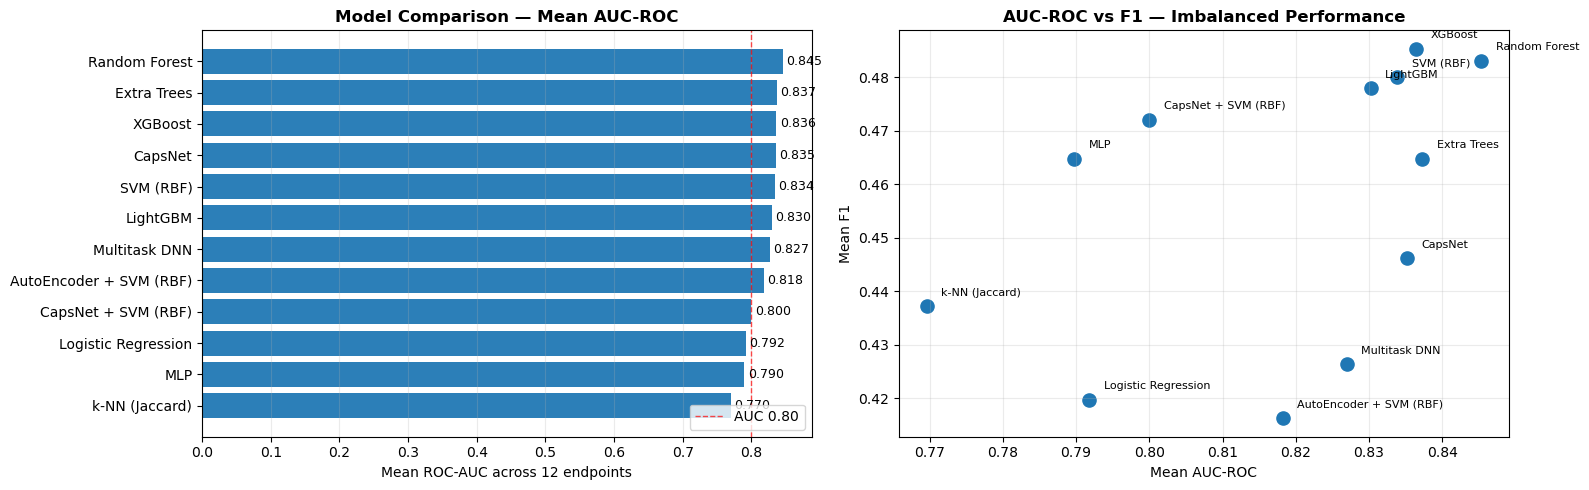

In [40]:
if len(model_summary):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    y_pos = np.arange(len(model_summary))
    axes[0].barh(y_pos, model_summary["Mean AUC-ROC"], color="#2c7fb8")
    axes[0].set_yticks(y_pos)
    axes[0].set_yticklabels(model_summary["Model"])
    axes[0].invert_yaxis()
    axes[0].axvline(0.80, color="red", linestyle="--", linewidth=1, alpha=0.7, label="AUC 0.80")
    axes[0].set_xlabel("Mean ROC-AUC across 12 endpoints")
    axes[0].set_title("Model Comparison — Mean AUC-ROC", fontweight="bold")
    axes[0].grid(axis="x", alpha=0.25)
    axes[0].legend(loc="lower right")
    for i, v in enumerate(model_summary["Mean AUC-ROC"]):
        axes[0].text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=9)

    axes[1].scatter(model_summary["Mean AUC-ROC"], model_summary["Mean F1"], s=90)
    for _, row in model_summary.iterrows():
        axes[1].text(row["Mean AUC-ROC"] + 0.002, row["Mean F1"] + 0.002, row["Model"], fontsize=8)
    axes[1].set_xlabel("Mean AUC-ROC")
    axes[1].set_ylabel("Mean F1")
    axes[1].set_title("AUC-ROC vs F1 — Imbalanced Performance", fontweight="bold")
    axes[1].grid(alpha=0.25)

    plt.tight_layout()
    plt.show()
else:
    print("No model summary available yet.")

## 26. Visualization 2 — AUC heatmap for all models × endpoints

প্রতিটি endpoint-এ কোন model ভালো করছে তা heatmap-এ দেখা হলো।

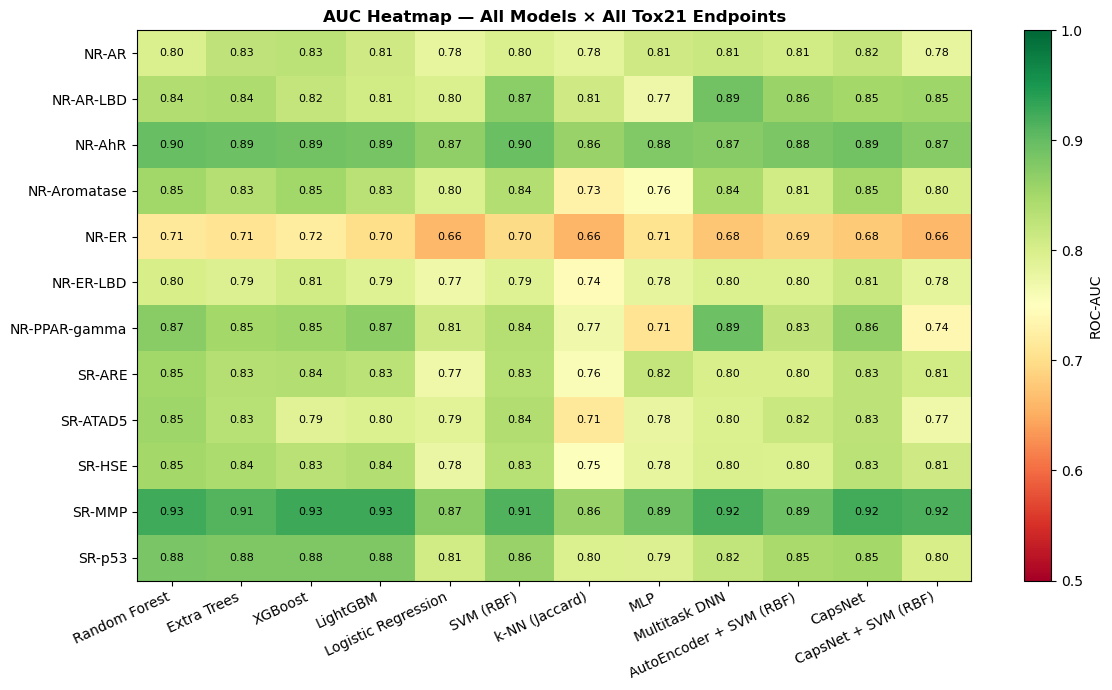

In [41]:
auc_table = pd.DataFrame(index=TARGET_COLS)
for model_name, result_df in all_results.items():
    if result_df is not None and len(result_df):
        auc_series = result_df.set_index("Endpoint")["AUC-ROC"]
        auc_table[model_name] = auc_series

if not auc_table.empty:
    plt.figure(figsize=(max(12, 0.9 * len(auc_table.columns)), 7))
    data = auc_table.values.astype(float)
    im = plt.imshow(data, aspect="auto", vmin=0.5, vmax=1.0, cmap="RdYlGn")
    plt.colorbar(im, label="ROC-AUC")
    plt.xticks(range(len(auc_table.columns)), auc_table.columns, rotation=25, ha="right")
    plt.yticks(range(len(auc_table.index)), auc_table.index)
    plt.title("AUC Heatmap — All Models × All Tox21 Endpoints", fontweight="bold")
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            val = data[i, j]
            if not np.isnan(val):
                plt.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print("No AUC table available yet.")

## 27. Visualization 3 — Requested 4 evaluation metrics for best model

AUC-ROC, Accuracy, Balanced Accuracy, F1-score — চারটি metric আলাদা plot-এ দেখানো হলো।

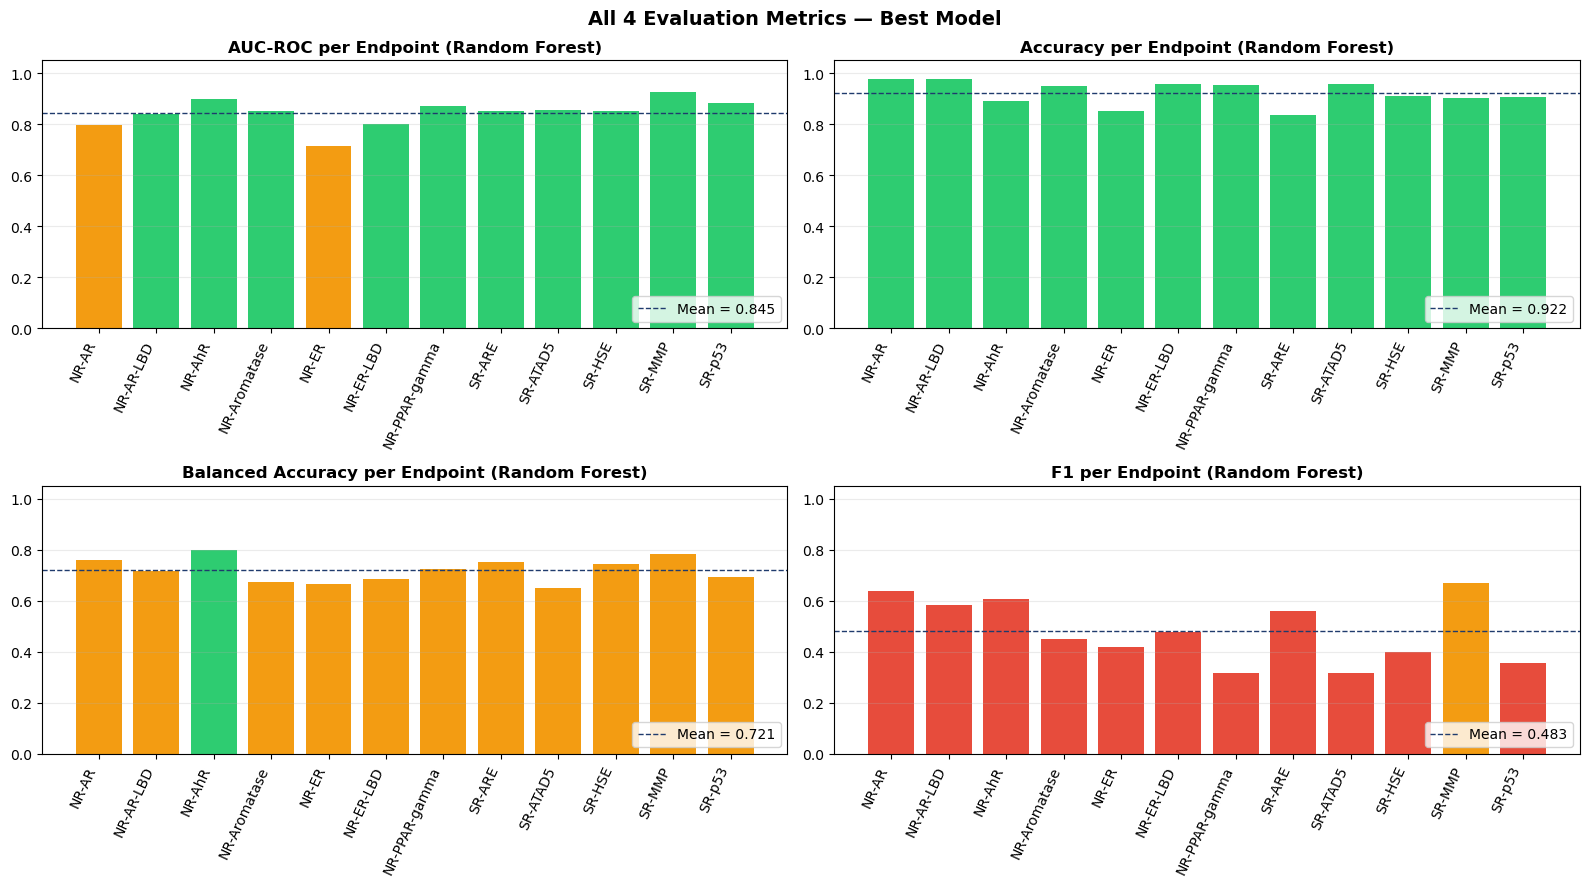

In [42]:
if len(model_summary):
    best_model_name = model_summary.iloc[0]["Model"]
    best_result = all_results[best_model_name].copy()

    metrics_to_plot = ["AUC-ROC", "Accuracy", "Balanced Accuracy", "F1"]
    fig, axes = plt.subplots(2, 2, figsize=(16, 9))
    axes = axes.ravel()

    for ax, metric in zip(axes, metrics_to_plot):
        values = best_result[metric].values
        colors = ["#2ecc71" if v >= 0.80 else "#f39c12" if v >= 0.65 else "#e74c3c" for v in values]
        ax.bar(best_result["Endpoint"], values, color=colors)
        ax.axhline(np.nanmean(values), color="#1f3b6d", linestyle="--", linewidth=1, label=f"Mean = {np.nanmean(values):.3f}")
        ax.set_title(f"{metric} per Endpoint ({best_model_name})", fontweight="bold")
        ax.set_ylim(0, 1.05)
        ax.set_xticklabels(best_result["Endpoint"], rotation=65, ha="right")
        ax.grid(axis="y", alpha=0.25)
        ax.legend(loc="lower right")

    plt.suptitle("All 4 Evaluation Metrics — Best Model", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("No best model available yet.")

## 28. Visualization 4 — Per-task AUC bar chart for best model

Screenshot-style endpoint-wise AUC bar chart।

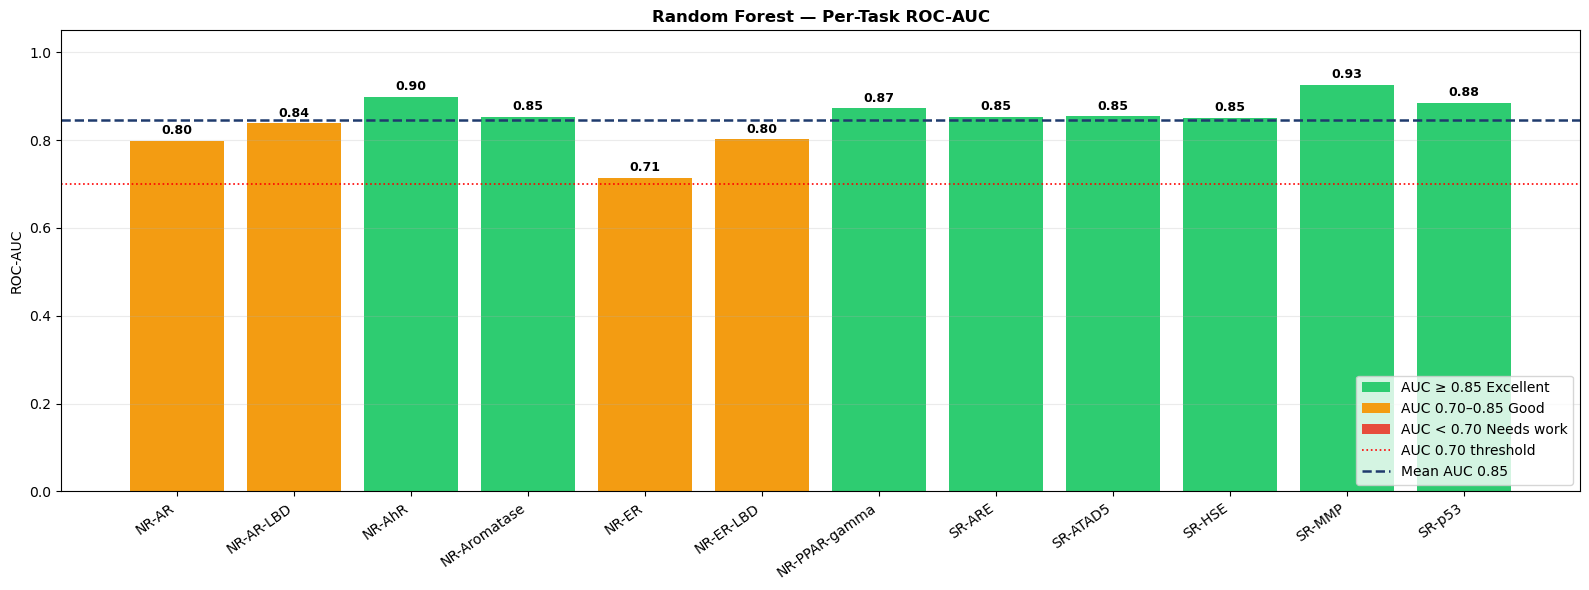

In [43]:
if len(model_summary):
    best_model_name = model_summary.iloc[0]["Model"]
    best_result = all_results[best_model_name].copy()

    auc_vals = best_result["AUC-ROC"].values
    colors = ["#2ecc71" if v >= 0.85 else "#f39c12" if v >= 0.70 else "#e74c3c" for v in auc_vals]

    plt.figure(figsize=(16, 6))
    plt.bar(best_result["Endpoint"], auc_vals, color=colors)
    plt.axhline(0.70, color="red", linestyle=":", linewidth=1.2, label="AUC 0.70 threshold")
    plt.axhline(np.nanmean(auc_vals), color="#1f3b6d", linestyle="--", linewidth=1.8, label=f"Mean AUC {np.nanmean(auc_vals):.2f}")
    plt.xticks(rotation=35, ha="right")
    plt.ylabel("ROC-AUC")
    plt.ylim(0, 1.05)
    plt.title(f"{best_model_name} — Per-Task ROC-AUC", fontweight="bold")
    plt.grid(axis="y", alpha=0.25)

    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor="#2ecc71", label="AUC ≥ 0.85 Excellent"),
        Patch(facecolor="#f39c12", label="AUC 0.70–0.85 Good"),
        Patch(facecolor="#e74c3c", label="AUC < 0.70 Needs work"),
    ]
    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(handles=legend_elements + handles, loc="lower right")

    for i, v in enumerate(auc_vals):
        plt.text(i, v + 0.015, f"{v:.2f}", ha="center", fontsize=9, fontweight="bold")

    plt.tight_layout()
    plt.show()

## 29. Visualization 5 — Confusion matrices: best endpoint vs hardest endpoint

Provided example-এর মতো best endpoint এবং hardest imbalanced endpoint compare করা হলো। Hardest endpoint সাধারণত lowest positive rate/maximum imbalance ratio।

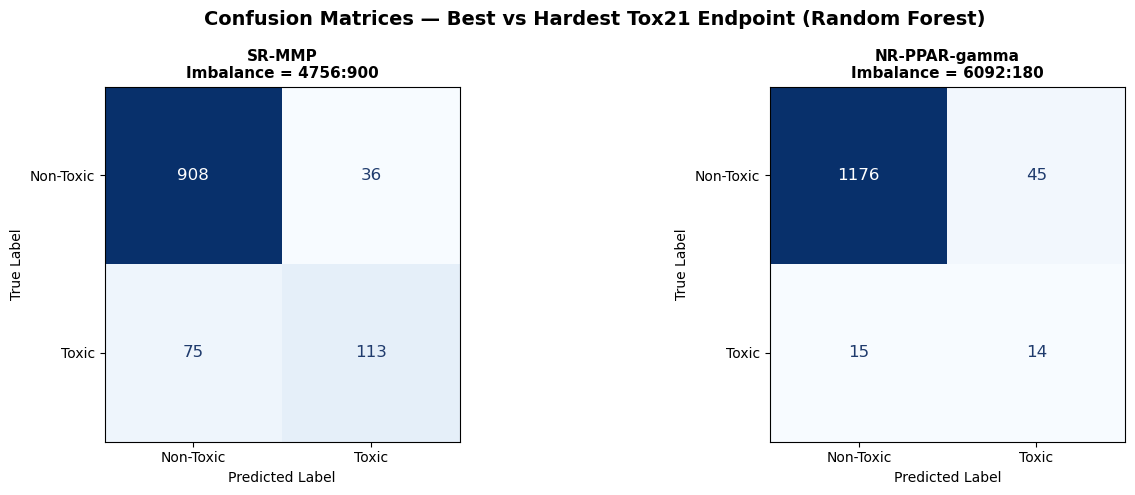

Note: NR-PPAR-gamma (33.7:1 ratio) is the hardest endpoint in the dataset by imbalance ratio.


In [45]:
if len(model_summary):
    best_model_name = model_summary.iloc[0]["Model"]
    best_result = all_results[best_model_name].copy()
    pred_store = all_test_predictions[best_model_name]

    # Best AUC endpoint
    best_endpoint = best_result.sort_values(
        "AUC-ROC", ascending=False
    ).iloc[0]["Endpoint"]

    # Most imbalanced endpoint
    hardest_endpoint = endpoint_summary.sort_values(
        "RatioValue", ascending=False
    ).iloc[0]["Endpoint"]

    endpoints_to_show = [best_endpoint, hardest_endpoint]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, endpoint in zip(axes, endpoints_to_show):

        y_true = pred_store[endpoint]["y_true"]
        y_pred = pred_store[endpoint]["y_pred"]

        cm = confusion_matrix(
            y_true,
            y_pred,
            labels=[0, 1]
        )

        ax.imshow(cm, cmap="Blues")

        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])

        ax.set_xticklabels(["Non-Toxic", "Toxic"])
        ax.set_yticklabels(["Non-Toxic", "Toxic"])

        ax.set_xlabel("Predicted Label")
        ax.set_ylabel("True Label")

        n_pos = int((df[endpoint].dropna().astype(int) == 1).sum())
        n_neg = int((df[endpoint].dropna().astype(int) == 0).sum())

        # Fixed title
        ax.set_title(
            f"{endpoint}\nImbalance = {n_neg}:{n_pos}",
            fontsize=11,
            fontweight="bold"
        )

        # Write confusion matrix values
        for i in range(2):
            for j in range(2):

                color = "white" if cm[i, j] > cm.max() / 2 else "#1f3b6d"

                ax.text(
                    j,
                    i,
                    str(cm[i, j]),
                    ha="center",
                    va="center",
                    fontsize=12,
                    color=color
                )

    plt.suptitle(
        f"Confusion Matrices — Best vs Hardest Tox21 Endpoint ({best_model_name})",
        fontsize=14,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()

    hard_row = endpoint_summary[
        endpoint_summary["Endpoint"] == hardest_endpoint
    ].iloc[0]

    print(
        f"Note: {hardest_endpoint} "
        f"({hard_row['RatioValue']:.1f}:1 ratio) "
        f"is the hardest endpoint in the dataset by imbalance ratio."
    )

## 30. Visualization 6 — 3-fold CV performance

3-fold cross-validation result model-wise compare করা হলো।

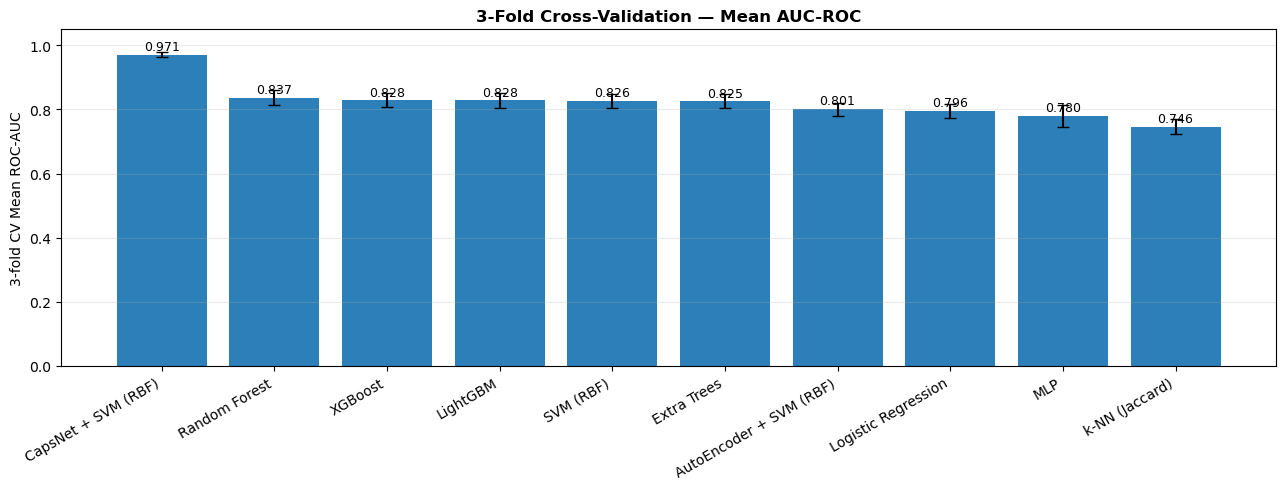

In [46]:
if len(cv_summary):
    plt.figure(figsize=(13, 5))
    x = np.arange(len(cv_summary))
    plt.bar(x, cv_summary["CV AUC-ROC Mean"], yerr=cv_summary["CV AUC-ROC Std Mean"], capsize=4, color="#2c7fb8")
    plt.xticks(x, cv_summary["Model"], rotation=30, ha="right")
    plt.ylabel("3-fold CV Mean ROC-AUC")
    plt.ylim(0, 1.05)
    plt.title("3-Fold Cross-Validation — Mean AUC-ROC", fontweight="bold")
    plt.grid(axis="y", alpha=0.25)
    for i, v in enumerate(cv_summary["CV AUC-ROC Mean"]):
        plt.text(i, v + 0.015, f"{v:.3f}", ha="center", fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print("No CV summary available.")

## 31. Save outputs

Results, CV summary, endpoint summary, trained preprocessing objects এবং notebook outputs save করা হলো।

In [47]:
# Save summary tables
endpoint_summary_display.to_csv(RESULT_DIR / "endpoint_missing_imbalance_summary.csv", index=False)
if len(model_summary):
    model_summary.to_csv(RESULT_DIR / "model_test_summary.csv", index=False)
if len(cv_summary):
    cv_summary.to_csv(RESULT_DIR / "model_3fold_cv_summary.csv", index=False)
if 'auc_table' in globals() and not auc_table.empty:
    auc_table.to_csv(RESULT_DIR / "auc_heatmap_table.csv")

# Save per-model per-endpoint test result
for model_name, result_df in all_results.items():
    safe_name = model_name.replace(" ", "_").replace("(", "").replace(")", "").replace("+", "plus")
    result_df.to_csv(RESULT_DIR / f"{safe_name}_per_endpoint_test_metrics.csv", index=False)

# Save preprocessing objects
joblib.dump({
    "imputer": imputer,
    "scaler": scaler,
    "target_cols": TARGET_COLS,
    "desc_names": desc_names,
    "n_bits": N_BITS,
    "radius": RADIUS,
}, RESULT_DIR / "preprocessing_objects.joblib")

print("Saved outputs to:", RESULT_DIR.resolve())

Saved outputs to: E:\Thesis_DrugToxicity\tox21_modified_outputs


## 32. Final researcher notes

এই modified notebook-এ requested changes applied:

1. Evaluation metrics এখন **AUC-ROC, Accuracy, Balanced Accuracy, F1-score**।  
2. Visuals updated: endpoint missing/imbalance, label distribution, AUC bar, heatmap, four-metric chart, confusion matrix।  
3. **SVM Linear বাদ দিয়ে RBF SVM** use করা হয়েছে।  
4. **Naive Bayes removed**।  
5. **3-fold cross-validation** add করা হয়েছে।  
6. **CapsNet + SVM RBF hybrid** block add করা হয়েছে।  

Research recommendation: final thesis/report-এ AUC-ROC-এর সাথে Balanced Accuracy ও F1 অবশ্যই দেখাবে, কারণ Tox21 highly imbalanced।